# Práctica: pyfingerprint en Python

**Materia:** Recuperación de la Información

`pyfingerprint` es una librería de Python para comunicarse con **sensores ópticos de huella digital** de la familia R30x (como el R305/R307/ZFM-20), muy usados en proyectos con Arduino/Raspberry Pi.

## ¿Para qué sirve?

Permite **capturar, almacenar y comparar huellas dactilares** usando un sensor físico conectado por UART (puerto serie): registrar una huella nueva, buscar si una huella ya está guardada (identificación 1:N) o verificar que corresponda a una persona específica (verificación 1:1). Es un ejemplo de recuperación de información **biométrica**: en vez de buscar texto, se busca la coincidencia de un patrón (la huella) contra una base de plantillas ya almacenadas.

## ¿Cómo funciona?

1. La librería se comunica con el sensor mediante un **protocolo de paquetes por puerto serie** (UART), enviando comandos binarios y leyendo las respuestas.
2. El sensor **captura la imagen** óptica de la huella (`readImage`) y la convierte en un conjunto de **características** (minucias: bifurcaciones y terminaciones de las crestas de la huella) mediante `convertImage`.
3. Esas características se pueden **guardar como plantilla** en la memoria del propio sensor (`storeTemplate`) o **compararse** contra las plantillas ya guardadas (`searchTemplate`, `compareCharacteristics`).

## ¿Qué tipo de operaciones se pueden realizar?

- **Conectarse** al sensor por puerto serie: `PyFingerprint(port, baudRate, address, password)`.
- **Leer una imagen** de huella cuando se coloca un dedo: `readImage()`.
- **Convertir** la imagen en características: `convertImage(bufferId)`.
- **Registrar** una nueva huella: `createTemplate()` + `storeTemplate()`.
- **Buscar** una huella entre todas las almacenadas: `searchTemplate()` (identificación 1:N).
- **Comparar** dos lecturas directamente: `compareCharacteristics()` (verificación 1:1).
- **Eliminar** una plantilla o **vaciar** toda la base.

## ¿Por qué no se puede usar el sensor de huella del teléfono?

`pyfingerprint` habla el **protocolo binario específico del chip R30x** (comandos y respuestas por UART tal como los define su datasheet). El sensor de huella de un celular (capacitivo o bajo la pantalla) **no es accesible desde una PC** para esto, y no es un límite de esta librería sino del diseño de seguridad de todos los sistemas operativos móviles modernos:

- En Android/iOS, la imagen o plantilla de la huella se procesa y se queda **encerrada dentro de un chip de seguridad aislado** (Secure Enclave / TEE), y **ni siquiera las apps del propio teléfono pueden leerla**: solo reciben un "sí/no coincide", nunca el dato biométrico crudo.
- No existe una API pública (ni oficial ni no oficial) para exponer ese sensor por USB/Bluetooth hacia una PC como si fuera un puerto serie.
- Por eso `pyfingerprint` (y cualquier librería similar) solo funciona con módulos **de hobby/embebidos** como el R30x, diseñados a propósito para exponer el dato crudo, a diferencia de un sensor de teléfono.

**Opciones reales para correr esta práctica con hardware de verdad:**

1. Comprar un módulo **R305/R307/ZFM-20** (~$5-15 USD en Amazon/MercadoLibre/AliExpress) + un adaptador USB-TTL si la laptop no tiene puerto serie directo.
2. Si solo tienes un lector USB tipo Windows Hello (huella capacitiva para laptop), tampoco sirve para `pyfingerprint`: esos usan un protocolo propietario distinto (WBDI) integrado con la API de Windows Hello, no el protocolo R30x.

Como no tenemos ese hardware disponible ahora, más abajo se incluye: (1) el código real y funcional para cuando sí se tenga el sensor, y (2) una **simulación** del algoritmo de coincidencia de huellas (usando vectores de minucias sintéticos) para que esta práctica sí muestre resultados reales corriendo, sin necesitar hardware.

## Parte 1: código real con el sensor físico

**Importante:** esta parte requiere el sensor R30x conectado por USB/serie (por ejemplo en `/dev/ttyUSB0` en Linux o `COM3` en Windows). Aquí se muestra el intento real de conexión, capturando el error esperado si no hay sensor.

In [1]:
from pyfingerprint.pyfingerprint import PyFingerprint

sensor = None
try:
    # En un equipo real con el sensor conectado, el puerto seria algo como
    # '/dev/ttyUSB0' (Linux) o 'COM3' (Windows)
    sensor = PyFingerprint('/dev/ttyUSB0', 57600, 0xFFFFFFFF, 0x00000000)
    if not sensor.verifyPassword():
        raise ValueError('La contraseña del sensor es incorrecta')
    print('Sensor conectado correctamente')
except Exception as e:
    print(f'No se pudo conectar al sensor ({type(e).__name__}): {e}')
    print('Esto es esperado en este entorno, ya que no hay un sensor de huella fisico conectado.')

No se pudo conectar al sensor (SerialException): [Errno 2] could not open port /dev/ttyUSB0: [Errno 2] No such file or directory: '/dev/ttyUSB0'
Esto es esperado en este entorno, ya que no hay un sensor de huella fisico conectado.


### Flujo de registro de una huella (enrolar)

Este bloque solo se ejecuta si el sensor sí se conectó arriba; en este entorno se mostrará el mensaje de que se omite, pero el código es el flujo real y funcional con hardware.

In [2]:
def enrolar_huella(sensor):
    print('Coloca tu dedo sobre el sensor...')
    while not sensor.readImage():
        pass
    sensor.convertImage(0x01)

    resultado_busqueda = sensor.searchTemplate()
    posicion = resultado_busqueda[0]
    if posicion >= 0:
        print(f'Esta huella ya esta registrada en la posicion #{posicion}')
        return

    print('Retira el dedo y vuelve a colocarlo para confirmar...')
    while sensor.readImage():
        pass
    while not sensor.readImage():
        pass
    sensor.convertImage(0x02)

    if sensor.compareCharacteristics() == 0:
        raise Exception('Las dos lecturas de la huella no coinciden')

    sensor.createTemplate()
    posicion_guardada = sensor.storeTemplate()
    print(f'Huella registrada correctamente en la posicion #{posicion_guardada}')

if sensor:
    enrolar_huella(sensor)
else:
    print('Omitido: se requiere un sensor fisico conectado para ejecutar este flujo.')

Omitido: se requiere un sensor fisico conectado para ejecutar este flujo.


### Flujo de búsqueda / identificación (1:N)

Compara la huella colocada contra **todas** las huellas almacenadas en el sensor.

In [3]:
def identificar_huella(sensor):
    print('Coloca tu dedo sobre el sensor para identificarte...')
    while not sensor.readImage():
        pass
    sensor.convertImage(0x01)

    resultado = sensor.searchTemplate()
    posicion, puntaje = resultado
    if posicion == -1:
        print('Huella no reconocida')
    else:
        print(f'Huella reconocida: plantilla #{posicion}, puntaje de confianza={puntaje}')

if sensor:
    identificar_huella(sensor)
else:
    print('Omitido: se requiere un sensor fisico conectado para ejecutar este flujo.')

Omitido: se requiere un sensor fisico conectado para ejecutar este flujo.


## Parte 2: simulación del algoritmo (sin hardware)

Para mostrar el **mismo flujo conceptual** (extraer características → guardar → comparar) sin depender del sensor físico, representamos cada huella como un conjunto de **minucias sintéticas**: puntos `(x, y, ángulo)` que imitan bifurcaciones/terminaciones de crestas. Esto **no reemplaza** al sensor real, es únicamente una demostración del algoritmo de coincidencia (matching) usado internamente por este tipo de sistemas.

In [4]:
import numpy as np

rng = np.random.default_rng(42)

def generar_minucias(n=25, semilla_base=None, ruido=0.0):
    """Genera un conjunto sintetico de minucias (x, y, angulo).
    Si se pasa semilla_base, genera una version 'ruidosa' de esas mismas minucias
    (simula dos lecturas del MISMO dedo, nunca son identicas al 100%)."""
    if semilla_base is None:
        pts = rng.uniform(0, 100, size=(n, 2))
        angulos = rng.uniform(0, 360, size=n)
        return np.column_stack([pts, angulos])
    else:
        pts = semilla_base.copy()
        pts[:, 0] += rng.normal(0, ruido, size=len(pts))
        pts[:, 1] += rng.normal(0, ruido, size=len(pts))
        pts[:, 2] += rng.normal(0, ruido * 2, size=len(pts))
        return pts

def puntaje_coincidencia(minucias_a, minucias_b, radio=4.0):
    """Cuenta cuantas minucias de A tienen una pareja cercana en B
    (posicion y angulo similares). Devuelve un puntaje 0-100."""
    coincidencias = 0
    usados = set()
    for xa, ya, aa in minucias_a:
        mejor = None
        mejor_d = radio
        for j, (xb, yb, ab) in enumerate(minucias_b):
            if j in usados:
                continue
            d = np.hypot(xa - xb, ya - yb)
            diff_ang = min(abs(aa - ab), 360 - abs(aa - ab))
            if d < mejor_d and diff_ang < 20:
                mejor_d = d
                mejor = j
        if mejor is not None:
            coincidencias += 1
            usados.add(mejor)
    return round(100 * coincidencias / len(minucias_a), 1)

print('Funciones de simulacion listas: generar_minucias(), puntaje_coincidencia()')

Funciones de simulacion listas: generar_minucias(), puntaje_coincidencia()


### 'Enrolar' una base de huellas simuladas

Creamos una pequeña base de datos con 3 huellas (personas) ya registradas.

In [5]:
base_huellas = {
    0: generar_minucias(n=25),
    1: generar_minucias(n=25),
    2: generar_minucias(n=25),
}
print(f'Base de datos simulada: {len(base_huellas)} huellas registradas (posiciones 0, 1, 2)')
for pos, m in base_huellas.items():
    print(f'  Huella #{pos}: {len(m)} minucias')

Base de datos simulada: 3 huellas registradas (posiciones 0, 1, 2)
  Huella #0: 25 minucias
  Huella #1: 25 minucias
  Huella #2: 25 minucias


### Verificación 1:1

Simulamos que la persona de la huella #1 vuelve a colocar el dedo (con ligero ruido natural en la lectura, como pasa siempre con sensores reales) y comparamos esa nueva lectura contra la plantilla #1.

In [6]:
lectura_nueva = generar_minucias(semilla_base=base_huellas[1], ruido=1.2)

puntaje = puntaje_coincidencia(lectura_nueva, base_huellas[1])
UMBRAL = 60.0
print(f'Puntaje de coincidencia contra plantilla #1: {puntaje}%')
print('Resultado:', 'COINCIDE (verificacion exitosa)' if puntaje >= UMBRAL else 'NO coincide')

Puntaje de coincidencia contra plantilla #1: 100.0%
Resultado: COINCIDE (verificacion exitosa)


### Identificación 1:N

Simulamos una lectura nueva de un dedo **desconocido** (no está en la base) y buscamos la mejor coincidencia contra las 3 huellas registradas.

In [7]:
lectura_desconocida = generar_minucias(n=25)  # dedo distinto, no registrado

print('Comparando la lectura contra cada huella de la base:')
mejor_pos, mejor_puntaje = -1, 0.0
for pos, m in base_huellas.items():
    p = puntaje_coincidencia(lectura_desconocida, m)
    print(f'  vs huella #{pos}: {p}%')
    if p > mejor_puntaje:
        mejor_pos, mejor_puntaje = pos, p

if mejor_puntaje >= UMBRAL:
    print(f'\nIdentificada como huella #{mejor_pos} (puntaje {mejor_puntaje}%)')
else:
    print(f'\nHuella no reconocida (mejor puntaje {mejor_puntaje}%, por debajo del umbral {UMBRAL}%)')

Comparando la lectura contra cada huella de la base:
  vs huella #0: 0.0%
  vs huella #1: 0.0%
  vs huella #2: 0.0%

Huella no reconocida (mejor puntaje 0.0%, por debajo del umbral 60.0%)


### Visualización de las minucias

Se grafican los puntos de la huella #1 original contra la nueva lectura (con ruido) para ver visualmente por qué el puntaje no es de 100%: el sensor nunca lee exactamente los mismos puntos dos veces, por eso se usa un umbral en vez de exigir una coincidencia perfecta.

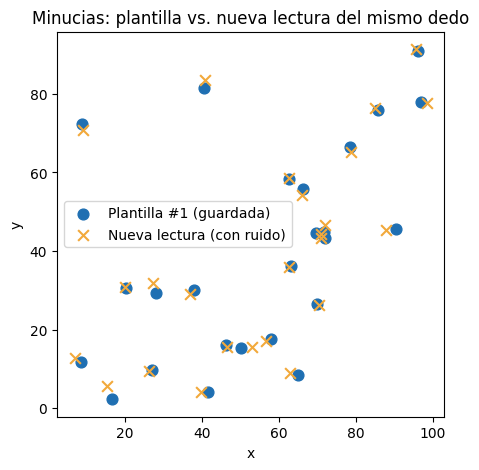

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,5))
orig = base_huellas[1]
ax.scatter(orig[:,0], orig[:,1], c='#1f6fb2', label='Plantilla #1 (guardada)', s=60)
ax.scatter(lectura_nueva[:,0], lectura_nueva[:,1], c='#f2a93b', marker='x', label='Nueva lectura (con ruido)', s=60)
ax.set_title('Minucias: plantilla vs. nueva lectura del mismo dedo')
ax.legend()
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.show()

## Conclusión

`pyfingerprint` traslada a Python el protocolo de un sensor biométrico real (R30x): capturar, convertir a características y comparar. No es posible conectarlo al sensor de huella de un teléfono porque los sistemas operativos móviles bloquean deliberadamente el acceso a esos datos por seguridad. La simulación de la Parte 2 no reemplaza al hardware, pero muestra el mismo principio que usa el sensor real: representar la huella como un conjunto de minucias y calcular un puntaje de similitud contra una base de plantillas, aceptando la coincidencia si supera un umbral (porque ninguna lectura biométrica es 100% idéntica a otra).